# 03 · H3 — 스타일 아키타입 + 개인화 벤치마크 (비지도)

**가설:** 셀러는 스타일 시그니처로 소수 아키타입으로 군집되며, 아키타입별
"잘 팔리는 표현 규범"이 다르다. 저성과 셀러는 자기 아키타입의 성공 규범에서
벗어나 있다 → 일반 조언 대신 "당신 유형의 잘 파는 셀러는 이렇게" 벤치마크.

**방법:** (1) 구조 시그니처로 아키타입 군집(KMeans, 전 셀러 커버),
(2) 아키타입 × sell-through (Kruskal-Wallis + Dunn),
(3) 아키타입 내 상/하위 셀러의 표현 격차 → 개인화 규범,
(4) wishlist 취향 네트워크 (보조).

In [1]:
import json
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import kruskal
import scikit_posthocs as sp

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"
CACHE = ROOT / "data" / "cache"

sel = pd.read_parquet(CACHE / "features_seller.parquet")
lst = pd.read_parquet(CACHE / "features_listing.parquet")

# 시그니처 안정성 위해 매물 5건 이상 셀러만 군집 대상
sel_c = sel[sel["n_listings"] >= 5].copy()
print(f"전체 셀러 {len(sel):,} → 군집대상(매물5+) {len(sel_c):,} ({len(sel_c)/len(sel):.0%})")

전체 셀러 11,095 → 군집대상(매물5+) 9,615 (87%)


## 1. 구조 시그니처로 아키타입 군집 (KMeans, k는 실루엣으로)

In [2]:
FEATS = ["brand_hhi", "brand_entropy_norm", "share_men", "share_new",
         "log_median_price", "avg_n_photos"]
Xs = sel_c[FEATS].fillna(sel_c[FEATS].median())
Xz = StandardScaler().fit_transform(Xs)

sil = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xz)
    sil[k] = silhouette_score(Xz, km.labels_, sample_size=5000, random_state=42)
best_k = max(sil, key=sil.get)
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
print("best k =", best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xz)
sel_c["archetype"] = km.labels_

silhouette by k: {3: 0.287, 4: 0.22, 5: 0.239, 6: 0.213, 7: 0.204, 8: 0.199}
best k = 3


## 2. 아키타입 특성 + 대표 브랜드

In [3]:
lst_c = lst.merge(sel_c[["seller_id", "archetype"]], on="seller_id", how="inner")
profile = sel_c.groupby("archetype").agg(
    n_sellers=("seller_id", "size"),
    sell_through=("sell_through", "mean"),
    brand_hhi=("brand_hhi", "mean"),
    share_men=("share_men", "mean"),
    share_new=("share_new", "mean"),
    median_price=("median_price", "median"),
    avg_n_photos=("avg_n_photos", "mean"),
).round(3)
# 대표 브랜드 top3
top_brands = {}
for a, g in lst_c.groupby("archetype"):
    top_brands[int(a)] = g["brand"].value_counts().head(3).index.tolist()
profile["top_brands"] = profile.index.map(lambda a: ", ".join(top_brands.get(a, [])))
print(profile.to_string())

           n_sellers  sell_through  brand_hhi  share_men  share_new  median_price  avg_n_photos                                         top_brands
archetype                                                                                                                                         
0               2377         0.242      0.132      0.206      0.184       70000.0         4.649            Japanese Vintage, Stone Island, Vintage
1               6574         0.215      0.129      0.936      0.182      142750.0         4.671              Stone Island, Polo Ralph Lauren, Nike
2                664         0.149      0.700      0.744      0.318      150000.0         5.201  Japanese Vintage, Stone Island, Polo Ralph Lauren


## 3. 아키타입 × sell-through 차이 검정 (Kruskal-Wallis + Dunn)

선행 연구는 가격만 봤다 — 여기선 전환율 차이가 핵심.

Kruskal-Wallis H=351.1, p=5.86e-77

Dunn posthoc (p, Bonferroni):
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


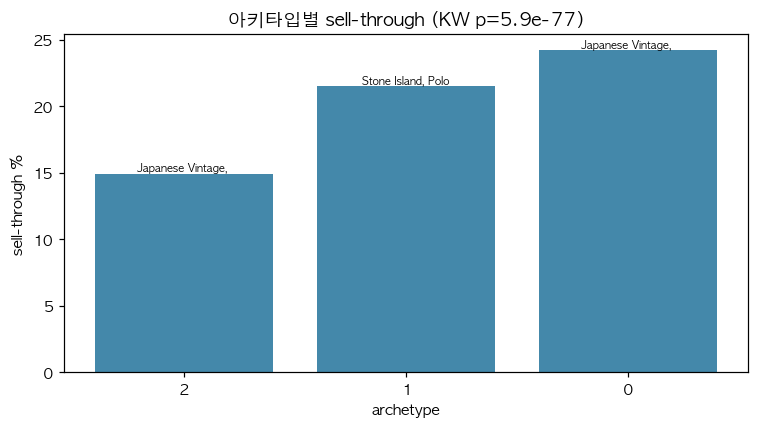

In [4]:
groups = [g["sell_through"].values for _, g in sel_c.groupby("archetype")]
H, p = kruskal(*groups)
print(f"Kruskal-Wallis H={H:.1f}, p={p:.2e}")
dunn = sp.posthoc_dunn(sel_c, val_col="sell_through", group_col="archetype", p_adjust="bonferroni")
print("\nDunn posthoc (p, Bonferroni):")
print(dunn.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
order = profile.sort_values("sell_through").index
ax.bar([str(a) for a in order], profile.loc[order, "sell_through"]*100, color="#48a")
ax.set(title=f"아키타입별 sell-through (KW p={p:.1e})", ylabel="sell-through %", xlabel="archetype")
for i, a in enumerate(order):
    ax.text(i, profile.loc[a, "sell_through"]*100+0.2, profile.loc[a, "top_brands"][:18],
            ha="center", fontsize=7, rotation=0)
fig.tight_layout(); fig.savefig(FIG / "h3_archetype_sellthrough.png", bbox_inches="tight"); plt.show()

## 4. 개인화 벤치마크 — 아키타입 내 상위 vs 하위 셀러의 표현 격차

셀러별 표현 평균을 구해, 같은 아키타입 안에서 sell-through 상위 33% vs 하위 33%가
표현(사진·설명·키워드·상대가격)에서 무엇이 다른지 → "당신 유형의 성공 규범".

아키타입별 상위−하위 셀러 표현 격차 (양수=성공셀러가 더 많이 함):
   n_photos  desc_len  kw_measure  kw_flaw  kw_material  kw_usage  relative_price_z
0    -0.714   -68.393      -0.145   -0.076       -0.127     0.045             0.134
1    -0.543   -28.976      -0.091   -0.083       -0.042    -0.001            -0.025
2    -0.716   -59.229      -0.141   -0.103       -0.063     0.009            -0.056


/tmp/claude-501/ipykernel_26752/2681895844.py:27: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.tight_layout(); fig.savefig(FIG / "h3_benchmark_gap.png", bbox_inches="tight"); plt.show()
/Users/ashcircle/Dev/ada/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


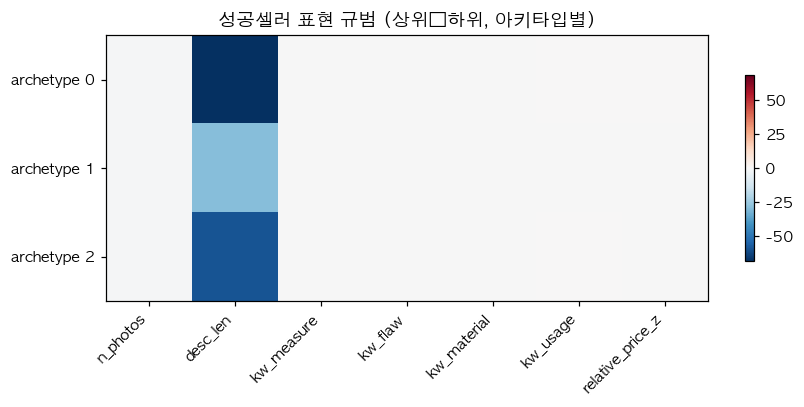

In [5]:
ctrl_cols = ["n_photos", "desc_len", "kw_measure", "kw_flaw", "kw_material",
             "kw_usage", "relative_price_z"]
seller_repr = lst_c.groupby("seller_id")[ctrl_cols].mean()
sel_b = sel_c.merge(seller_repr, on="seller_id", how="left")

bench = {}
for a, g in sel_b.groupby("archetype"):
    if len(g) < 30:
        continue
    hi = g[g["sell_through"] >= g["sell_through"].quantile(0.67)]
    lo = g[g["sell_through"] <= g["sell_through"].quantile(0.33)]
    bench[int(a)] = {c: {"top": round(hi[c].mean(), 3), "bottom": round(lo[c].mean(), 3),
                         "gap": round(hi[c].mean() - lo[c].mean(), 3)} for c in ctrl_cols}

# 격차를 한눈에 — 아키타입별 (top-bottom) 히트맵
gap_df = pd.DataFrame({a: {c: v[c]["gap"] for c in ctrl_cols} for a, v in bench.items()}).T
print("아키타입별 상위−하위 셀러 표현 격차 (양수=성공셀러가 더 많이 함):")
print(gap_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 0.6*len(gap_df)+2))
im = ax.imshow(gap_df.values, cmap="RdBu_r", aspect="auto",
               vmin=-np.abs(gap_df.values).max(), vmax=np.abs(gap_df.values).max())
ax.set_xticks(range(len(ctrl_cols))); ax.set_xticklabels(ctrl_cols, rotation=45, ha="right")
ax.set_yticks(range(len(gap_df))); ax.set_yticklabels([f"archetype {a}" for a in gap_df.index])
ax.set_title("성공셀러 표현 규범 (상위−하위, 아키타입별)")
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout(); fig.savefig(FIG / "h3_benchmark_gap.png", bbox_inches="tight"); plt.show()

## 5. wishlist 취향 네트워크 (보조, 958셀러 서브셋)

찜한 매물의 브랜드로 셀러 취향벡터 → 취향 유사도가 같은 아키타입에 모이는지.

In [6]:
with sqlite3.connect(ROOT / "data" / "fruitsfamily.db") as conn:
    wl = pd.read_sql_query("SELECT owner_seller_id, product_id FROM wishlist", conn)
brand_map = lst.set_index("product_id")["brand"]
wl["brand"] = wl["product_id"].map(brand_map)
wl = wl.dropna(subset=["brand"])
n_owners = wl["owner_seller_id"].nunique()
print(f"wishlist owner {n_owners} | 브랜드 매핑된 찜 {len(wl):,}")

# 취향 집중도(찜 브랜드 HHI)와 본인 sell_through 관계
def hhi(s):
    p = s.value_counts(normalize=True)
    return (p**2).sum()
taste = wl.groupby("owner_seller_id")["brand"].agg(hhi).rename("wish_brand_hhi").reset_index()
taste = taste.merge(sel[["seller_id", "sell_through", "n_listings"]],
                    left_on="owner_seller_id", right_on="seller_id", how="inner")
corr = taste[["wish_brand_hhi", "sell_through"]].corr().iloc[0, 1]
print(f"찜 브랜드 집중도 ↔ 본인 sell-through 상관: r={corr:.3f} (n={len(taste)})")

wishlist owner 950 | 브랜드 매핑된 찜 23,376


찜 브랜드 집중도 ↔ 본인 sell-through 상관: r=-0.120 (n=950)


## 6. 저장 — seller_clusters.parquet 재생성 + results/h3.json

In [7]:
sel_c[["seller_id", "archetype"]].to_parquet(CACHE / "seller_clusters.parquet", index=False)

h3 = {
    "n_sellers_clustered": int(len(sel_c)),
    "coverage_of_all_sellers": round(len(sel_c)/len(sel), 3),
    "best_k": int(best_k),
    "silhouette": {int(k): round(v, 3) for k, v in sil.items()},
    "archetype_profile": json.loads(profile.reset_index().to_json(orient="records", force_ascii=False)),
    "kruskal": {"H": round(float(H), 2), "p": float(p)},
    "sellthrough_range_across_archetypes": [round(float(profile["sell_through"].min()), 3),
                                            round(float(profile["sell_through"].max()), 3)],
    "benchmark_gap": bench,
    "wishlist": {"n_owners_mapped": int(n_owners),
                 "wish_hhi_vs_sellthrough_corr": round(float(corr), 3)},
}
(ROOT / "results" / "h3.json").write_text(
    json.dumps(h3, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved. archetypes:", best_k, "| sell-through range:",
      h3["sellthrough_range_across_archetypes"])

saved. archetypes: 3 | sell-through range: [0.149, 0.242]
